# Hierarchy example
This notebook provides a toy example on how to perform hierarchical reconciliation using the PyOnlineForecast package.

It uses artificial data from an AR(2) process (Møller et al., 2024). The case uses a temporal hierarchy,

$$
Y_{A, t} = Y_{H, t-1} + Y_{H, t}.
$$

i.e. the "annual" level is defined in terms of the two past "half-year" observations. The notebook covers,
- use of ``TemporalRidgeReconciliation`` for temporal hierarchies,
- use of ``RidgeReconciliation`` for general hierarchies

We begin by importing the simulated data and base forecasts,

In [1]:
from py_online_forecast.datasets import sample_hierarchical_data as data
data.head()

Variable       Y_A       Y_H  pred_Y_A  pred_Y_H          
Horizon          0         0         2         1         2
0        -4.106624 -2.899548 -3.833273 -2.652854 -2.427148
1        -5.258503 -2.358955 -4.913041 -2.157604 -1.973439
2        -5.507629 -3.148674 -5.147808 -2.882293 -2.638449
3        -6.273564 -3.124891 -5.869046 -2.861292 -2.619928
4        -6.357276 -3.232386 -5.949235 -2.960922 -2.712257

The data is organized so that the i´th row contains the annual observations, $Y_{A,i}$, half-year observations $Y_{H,i}$, annual prediction $\hat{Y}_{A, t+2}$ and half year predictions $\hat{Y}_{H,i+1}$, $\hat{Y}_{H,i+2}$.

To perform forecast reconciliation, we first use the ``TemporalRidgeReconciliation`` class to model the data directly as a temporal hierarchy. This means defining a summation matrix to encode the hierarchy, and a back-shift structure to map bottom level observations $Y_{H,i}$, $i = 1, 2, ...$  to the bottom level of the hierarchy, i.e. the vector $(Y_{H, i-1}, Y_{H, i})$. Behind the scenes, the class uses ``RRR`` from the ``prediciton`` module. By default, parameters are thus updated recursively with every new row of data. For a temporal hierarchy, bottom level observations are constructed by back-shifting observations. Updating parameters with each new row thus implies reusing some data. We can avoid this by setting the ``skip_duplicates`` flag.

In [2]:
import numpy as np
from py_online_forecast.hierarchies import TemporalRidgeReconciliation

# Define the summation matrix
S = np.array([[1, 1], [1, 0], [0, 1]])
S_top = S[[0]]

# Define the back-shift structure
B = [1, 0]  # [Y_{H,t-1}, Y_{H,t-0}]

# Define the reconciler
temporal_reconciler = TemporalRidgeReconciliation(
    S_top,                      # Summation matrix for top level
    B,                          # Back-shift structure
    full_cov=True,              # Whether to estimate full covariance in bottom levels
    skip_duplicates=True,       # Whether to skip duplicate lagged data
    opt_shrink=False,           # Whether to use ``SRRR`` instead of ``RRR``
    full_hierarchy_cov=False,   # Whether to output full covariance matrix of hierarchy
)

# We also set the ForecastFormat to ensure outputs are formatted similarly to inputs
from py_online_forecast.forecast_tools import ForecastFormat
temporal_reconciler.set_format(ForecastFormat)

>Note: by default, ``TemporalRidgeReconciliation`` will infer the prediction horizon based on the back-shift structure, as $\max(B) + 1$. This behaviour can be overwritten by explicitly passing the ``horizon`` argument.

To apply the reconciler, we can use the ``fit`` method,

In [3]:
# Get the data
data_Y_hat = data[["pred_Y_A","pred_Y_H"]]
data_Y_bot = data[["Y_H"]]

# Fit the reconciler
res = temporal_reconciler.fit(data_Y_bot, data_Y_hat)

The result is a dict, with predicted means under the "mean" key,

In [4]:
res["mean"].head()

Variable  pred_Y_A  pred_Y_H          
Horizon          2         1         2
0              NaN       NaN       NaN
1              NaN       NaN       NaN
2              NaN       NaN       NaN
3        -6.543789 -3.352806 -3.190983
4        -6.429518 -3.310783 -3.118735

And predicted covariances under the "cov" key,

In [5]:
res["cov"].head(9)

Variable  pred_Y_A  pred_Y_H          
Horizon          2         1         2
0              NaN       NaN       NaN
1              NaN       NaN       NaN
2              NaN       NaN       NaN
3              NaN       NaN       NaN
4              NaN       NaN       NaN
5         0.003283  0.000234  0.001765
6         0.002496  0.002192  0.001657
7         0.005333  0.003076  0.003400
8         0.010566  0.002222  0.008920

The same results can be achieved in an online setting. We can test this, by emulating online updates, i.e. passing one new row of data at a time,

In [28]:
import pandas as pd

# First, reset the state of the reconciler
temporal_reconciler.reset_state()

# Then, loop over rows in the data and update the reconciler one step at a time
result = []
result_cov  = []
for t in range(len(data_Y_bot)):
    Y_bot_t = data_Y_bot.iloc[[t]]
    Y_hat_t = data_Y_hat.iloc[[t]]
    rec_t = temporal_reconciler.update(Y_bot_t, Y_hat_t)
    result.append(rec_t["mean"])
    result_cov.append(rec_t["cov"])

# Concatenate the results
result_df = pd.concat(result)
result_cov_df = pd.concat(result_cov)
result_df.head()

Variable  pred_Y_A  pred_Y_H          
Horizon          2         1         2
0              NaN       NaN       NaN
1              NaN       NaN       NaN
2              NaN       NaN       NaN
3        -6.543789 -3.352806 -3.190983
4        -6.429518 -3.310783 -3.118735

For structural hierarchies, the above approach is not applicable. Instead of a single bottom level observation, we are given observations on a set of bottom levels. We can demonstrate how reconciliation in such hierarchies is handled in the PyOnlineForecast package by first normalizing the input data. This is the same procedure, that the ``TemporalRidgeReconciliation`` object handles internally. Both ``RidgeReconciliation`` and ``TemporalRidgeReconciliation`` are transformations and support the same methods. Furthermore, the data inputs, i.e. base forecasts and bottom level observations, can be configured as sources. In fact, the ``TemporalRidgeReconciliation`` is implemented by passing base forecasts and back-shifted observations as source inputs to the ``RidgeReconciliation`` class. The implementation is more or less,

In [41]:
from py_online_forecast.core import Source
from py_online_forecast.prediction import BackShift
from py_online_forecast.hierarchies import RidgeReconciliation

# Define sources
Z_bot = Source("Z_bot") # Observations
Y_hat = Source("Y_hat") # Base forecasts for bottom level

Y_bot_full = BackShift(B, Z_bot) # Full bottom level "observations"

reconciler = RidgeReconciliation(S_top, Y_bot = Y_bot_full, Y_hat = Y_hat, horizon = 2, opt_shrink = False, temporal_skip=True)
reconciler.set_format(ForecastFormat)

# Call the reconciler with the data (using the transfomation interface)
rec_result = reconciler({Z_bot: data_Y_bot, Y_hat: data_Y_hat})

rec_result["mean"].head()

Variable  pred_Y_A  pred_Y_H          
Horizon          2         1         2
0              NaN       NaN       NaN
1              NaN       NaN       NaN
2              NaN       NaN       NaN
3        -6.543789 -3.352806 -3.190983
4        -6.429518 -3.310783 -3.118735

Finally, we can plot the results.

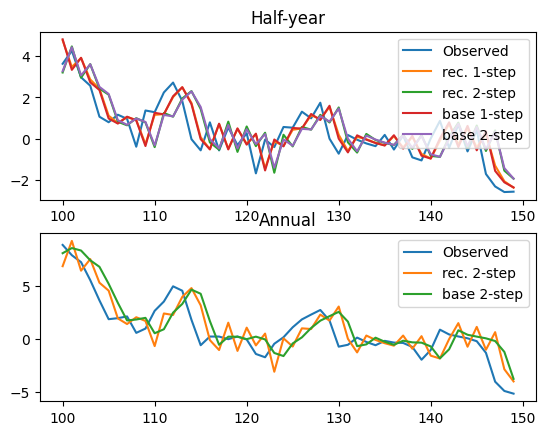

In [39]:
import matplotlib.pyplot as plt


Y_hat_rec = rec_result["mean"]

data_Y_top = data[["Y_A"]]

n_start = 100
n_plot = 50
fig, (ax1, ax2) = plt.subplots(2, 1)

ax1.set_title("Half-year")
data_Y_bot.iloc[n_start:n_start + n_plot].plot(ax=ax1)
Y_hat_rec[["pred_Y_H"]].fc.lag().iloc[n_start:n_start + n_plot].plot(ax=ax1)
data_Y_hat[["pred_Y_H"]].fc.lag().iloc[n_start:n_start + n_plot].plot(ax=ax1)
ax1.legend(["Observed", "rec. 1-step", "rec. 2-step", "base 1-step", "base 2-step"])

ax2.set_title("Annual")
data_Y_top.iloc[n_start:n_start + n_plot].plot(ax=ax2)
Y_hat_rec[["pred_Y_A"]].fc.lag().iloc[n_start:n_start + n_plot].plot(ax=ax2)
data_Y_hat[["pred_Y_A"]].fc.lag().iloc[n_start:n_start + n_plot].plot(ax=ax2)
ax2.legend(["Observed", "rec. 2-step", "base 2-step"])


And the residuals

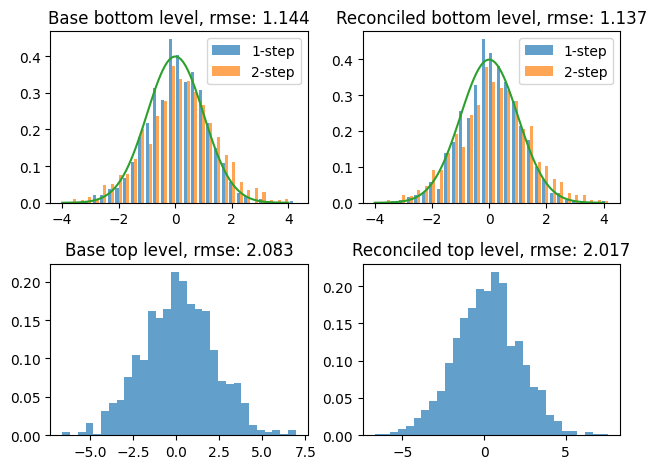

In [40]:
from py_online_forecast.prediction import rmse

resid_base_bot = -data_Y_hat[["pred_Y_H"]].fc.lag().sub(data_Y_bot.to_numpy(), axis = 0)
resid_base_top = -data_Y_hat[["pred_Y_A"]].fc.lag().sub(data_Y_top.to_numpy())
resid_rec_bot = -Y_hat_rec[["pred_Y_H"]].fc.lag().sub(data_Y_bot.to_numpy(), axis = 0)
resid_rec_top = -Y_hat_rec[["pred_Y_A"]].fc.lag().sub(data_Y_top.to_numpy())

rmse_base_bot = rmse(resid_base_bot)
rmse_base_top = rmse(resid_base_top)
rmse_rec_bot = rmse(resid_rec_bot)
rmse_rec_top = rmse(resid_rec_top)

# Make histograms
fig, axes = plt.subplots(2, 2)
axes[0, 0].hist(resid_base_bot.dropna(), bins=30, alpha=0.7, density = True)
axes[0, 0].legend(["1-step", "2-step"])
axes[0, 0].set_title(f"Base bottom level, rmse: {rmse_base_bot:.3f}")
axes[0, 1].hist(resid_rec_bot.dropna(), bins=30, alpha=0.7, density = True)
axes[0, 1].legend(["1-step", "2-step"])
axes[0, 1].set_title(f"Reconciled bottom level, rmse: {rmse_rec_bot:.3f}")

# Also include gaussian with unity variance (true noise distribution) for reference
x = np.linspace(-4, 4, 100)
y = 1/np.sqrt(2 * np.pi) * np.exp(-0.5 * x**2)
axes[0, 0].plot(x, y)
axes[0, 1].plot(x, y)

# Top level
axes[1, 0].hist(resid_base_top.dropna(), bins=30, alpha=0.7, density = True)
axes[1, 0].set_title(f"Base top level, rmse: {rmse_base_top:.3f}")
axes[1, 1].hist(resid_rec_top.dropna(), bins=30, alpha=0.7, density = True)
axes[1, 1].set_title(f"Reconciled top level, rmse: {rmse_rec_top:.3f}")
plt.tight_layout()
